In [6]:
def define_discriminator(image_shape):
	# This method defines and compiles a PatchGAN discriminator for Pix2Pix.
  # It takes an image pair as input, processes them through convolutional layers,
  # and outputs a patch-wise classification of real or fake regions.

	# Initialize weights with a normal distribution (stddev=0.02), as recommended for GANs
	init = RandomNormal(stddev=0.02)
	# Define input layers: source image and target image
	in_src_image = Input(shape=image_shape)
	in_target_image = Input(shape=image_shape)
	merged = Concatenate()([in_src_image, in_target_image])

	# First convolutional layer (C64)
	d = Conv2D(64, (4,4), strides=(2,2), padding='same', kernel_initializer=init)(merged)
	d = LeakyReLU(alpha=0.2)(d)
	# Second convolutional layer (C128)
	d = Conv2D(128, (4,4), strides=(2,2), padding='same', kernel_initializer=init)(d)
	d = BatchNormalization()(d)
	d = LeakyReLU(alpha=0.2)(d)
	# Third convolutional layer (C256)
	d = Conv2D(256, (4,4), strides=(2,2), padding='same', kernel_initializer=init)(d)
	d = BatchNormalization()(d)
	d = LeakyReLU(alpha=0.2)(d)
	# Fourth convolutional layer (C512)
	d = Conv2D(512, (4,4), strides=(2,2), padding='same', kernel_initializer=init)(d)
	d = BatchNormalization()(d)
	d = LeakyReLU(alpha=0.2)(d)
	# Additional convolutional layer before the output
	d = Conv2D(512, (4,4), padding='same', kernel_initializer=init)(d)
	d = BatchNormalization()(d)
	d = LeakyReLU(alpha=0.2)(d)
	# Final layer with a single filter to output a probability map (PatchGAN output)
	d = Conv2D(1, (4,4), padding='same', kernel_initializer=init)(d)
	patch_out = Activation('sigmoid')(d)

	# Define the model with input images and output patch-wise classification
	model = Model([in_src_image, in_target_image], patch_out)
	# Compile the model with binary cross-entropy loss and Adam optimizer
	opt = Adam(learning_rate=0.0002, beta_1=0.5)
	model.compile(loss='binary_crossentropy', optimizer=opt, loss_weights=[0.5])
	return model

In [5]:
def define_encoder_block(layer_in, n_filters, batchnorm=True):
	# This method defines an encoder block for the generator model in Pix2Pix.
  # It applies a convolutional downsampling layer, optionally followed by batch normalization,
  # and uses LeakyReLU activation.
	# weight initialization
	init = RandomNormal(stddev=0.02)
	# add downsampling layer
	g = Conv2D(n_filters, (4,4), strides=(2,2), padding='same', kernel_initializer=init)(layer_in)
	# conditionally add batch normalization
	if batchnorm:
		g = BatchNormalization()(g, training=True)
	# leaky relu activation
	g = LeakyReLU(alpha=0.2)(g)
	return g

def decoder_block(layer_in, skip_in, n_filters, dropout=True):
	# This method defines a decoder block for the generator model in Pix2Pix.
  # It applies a transposed convolution (upsampling), batch normalization,
  # optional dropout, and concatenation with the corresponding encoder layer.
	# weight initialization
	init = RandomNormal(stddev=0.02)
	# add upsampling layer
	g = Conv2DTranspose(n_filters, (4,4), strides=(2,2), padding='same', kernel_initializer=init)(layer_in)
	# add batch normalization
	g = BatchNormalization()(g, training=True)
	# conditionally add dropout
	if dropout:
		g = Dropout(0.5)(g, training=True)
	# merge with skip connection
	g = Concatenate()([g, skip_in])
	# relu activation
	g = Activation('relu')(g)
	return g

def define_generator(image_shape=(256,256,3)):
	# This method defines the generator model for Pix2Pix.
  # Follows a U-Net architecture, consisting of an encoder that compresses the input,
  # a bottleneck layer, and a decoder that reconstructs the output image.
	# weight initialization
	init = RandomNormal(stddev=0.02)
	in_image = Input(shape=image_shape)
	# encoder model
	e1 = define_encoder_block(in_image, 64, batchnorm=False)
	e2 = define_encoder_block(e1, 128)
	e3 = define_encoder_block(e2, 256)
	e4 = define_encoder_block(e3, 512)
	e5 = define_encoder_block(e4, 512)
	e6 = define_encoder_block(e5, 512)
	e7 = define_encoder_block(e6, 512)
	# bottleneck, no batch norm and relu
	b = Conv2D(512, (4,4), strides=(2,2), padding='same', kernel_initializer=init)(e7)
	b = Activation('relu')(b)
	# decoder model
	d1 = decoder_block(b, e7, 512)
	d2 = decoder_block(d1, e6, 512)
	d3 = decoder_block(d2, e5, 512)
	d4 = decoder_block(d3, e4, 512, dropout=False)
	d5 = decoder_block(d4, e3, 256, dropout=False)
	d6 = decoder_block(d5, e2, 128, dropout=False)
	d7 = decoder_block(d6, e1, 64, dropout=False)
	# output layer
	g = Conv2DTranspose(3, (4,4), strides=(2,2), padding='same', kernel_initializer=init)(d7)
	out_image = Activation('tanh')(g)

	model = Model(in_image, out_image)
	return model

In [4]:
def define_gan(g_model, d_model, image_shape):
	# This method defines the combined GAN model for Pix2Pix,
  # which consists of a generator and a discriminator.
  # The discriminator is frozen during generator training to ensure stable learning.

	# make weights in the discriminator not trainable
	for layer in d_model.layers:
		if not isinstance(layer, BatchNormalization):
			layer.trainable = False

	in_src = Input(shape=image_shape)
	# connect the source image to the generator input
	gen_out = g_model(in_src)
	# connect the source input and generator output to the discriminator input
	dis_out = d_model([in_src, gen_out])
	# src image as input, generated image and classification output
	model = Model(in_src, [dis_out, gen_out])
	# Compile the model with binary cross-entropy loss for the discriminator
	# and mean absolute error (MAE) loss for the generator
	opt = Adam(learning_rate=0.0002, beta_1=0.5)
	model.compile(loss=['binary_crossentropy', 'mae'], optimizer=opt, loss_weights=[1,100])
	return model

In [20]:
import numpy as np
# load and prepare training images
def load_real_samples(filename):
	# load compressed arrays
	data = load(filename)
	# unpack arrays
	X1, X2 = data['arr_0'], data['arr_1']
	# X1, X2 = data['src'], data['tar']
	# scale from [0,255] to [-1,1]
	X1 = (X1 - 127.5) / 127.5
	X2 = (X2 - 127.5) / 127.5
	return [X1, X2]

def load_real_samples_from_zip(zip_filename):
    """Load images from a ZIP file, split them into two parts, and normalize."""

    src_list, tar_list = [], []

    # Open ZIP file
    with zipfile.ZipFile(zip_filename, 'r') as archive:
        image_filenames = [f for f in archive.namelist() if f.endswith(('.png', '.jpg', '.jpeg'))]

        for img_name in sorted(image_filenames):
            with archive.open(img_name) as file:
                # Read image
                image = cv2.imdecode(np.frombuffer(file.read(), np.uint8), cv2.IMREAD_COLOR)

                if image is None or image.shape[:2] != (256, 512):
                    print(f"Skipping {img_name}, invalid shape.")
                    continue

								# Convert from BGR (OpenCV format) to RGB
                image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

                # Split into two 256x256 images
                src_img = image[:, :256]  # Left side (photo)
                tar_img = image[:, 256:]  # Right side (drawing)

                # Normalize to [-1, 1]
                src_img = (src_img.astype(np.float32) - 127.5) / 127.5
                tar_img = (tar_img.astype(np.float32) - 127.5) / 127.5

                src_list.append(src_img)
                tar_list.append(tar_img)

    # Convert lists to NumPy arrays
    X1, X2 = np.array(src_list), np.array(tar_list)

    print(f"Loaded {X1.shape[0]} images from {zip_filename}")
    return [X1, X2]

# select a batch of random samples, returns images and target
def generate_real_samples(dataset, n_samples, patch_shape):
	# unpack dataset
	trainA, trainB = dataset
	# choose random instances
	ix = randint(0, trainA.shape[0], n_samples-1)
	ix = np.array(ix)
	# retrieve selected images
	X1, X2 = trainA[ix], trainB[ix]
	# generate 'real' class labels (1)
	y = ones((n_samples, patch_shape, patch_shape, 1))
	return [X1, X2], y

# generate a batch of images, returns images and targets
def generate_fake_samples(g_model, samples, patch_shape):
	# generate fake instance
	X = g_model.predict(samples)
	# create 'fake' class labels (0)
	y = zeros((len(X), patch_shape, patch_shape, 1))
	return X, y

# generate samples and save as a plot and save the model
def summarize_performance(step, g_model, dataset, output_path, n_samples=3):
	# select a sample of input images
	[X_realA, X_realB], _ = generate_real_samples(dataset, n_samples, 1)
	# generate a batch of fake samples
	X_fakeB, _ = generate_fake_samples(g_model, X_realA, 1)
	# scale all pixels from [-1,1] to [0,1]
	X_realA = (X_realA + 1) / 2.0
	X_realB = (X_realB + 1) / 2.0
	X_fakeB = (X_fakeB + 1) / 2.0
	# plot real source images
	for i in range(n_samples):
		pyplot.subplot(3, n_samples, 1 + i)
		pyplot.axis('off')
		pyplot.imshow(X_realA[i])
	# plot generated target image
	for i in range(n_samples):
		pyplot.subplot(3, n_samples, 1 + n_samples + i)
		pyplot.axis('off')
		pyplot.imshow(X_fakeB[i])
	# plot real target image
	for i in range(n_samples):
		pyplot.subplot(3, n_samples, 1 + n_samples*2 + i)
		pyplot.axis('off')
		pyplot.imshow(X_realB[i])
	# save plot to file
	filename1 = output_path + 'plot_%06d.png' % (step+1)
	pyplot.savefig(filename1)
	pyplot.close()
	# save the generator model
	# filename2 = output_path + 'model_%06d.h5' % (step+1)
	# g_model.save(filename2)
	# print('>Saved: %s and %s' % (filename1, filename2))

In [2]:
# train pix2pix model
def train(d_model, g_model, gan_model, dataset, output_path, n_epochs=5, n_batch=1):
	# determine the output square shape of the discriminator
	n_patch = d_model.output_shape[1]
	# unpack dataset
	trainA, trainB = dataset
	# calculate the number of batches per training epoch
	bat_per_epo = int(len(trainA) / n_batch)
	# calculate the number of training iterations
	n_steps = bat_per_epo * n_epochs
	# manually enumerate epochs
	for i in range(n_steps):
		# select a batch of real samples
		[X_realA, X_realB], y_real = generate_real_samples(dataset, n_batch, n_patch)
		# generate a batch of fake samples
		X_fakeB, y_fake = generate_fake_samples(g_model, X_realA, n_patch)
		# update discriminator for real samples
		d_loss1 = d_model.train_on_batch([X_realA, X_realB], y_real)
		# update discriminator for generated samples
		d_loss2 = d_model.train_on_batch([X_realA, X_fakeB], y_fake)
		# update the generator
		g_loss, _, _ = gan_model.train_on_batch(X_realA, [y_real, X_realB])
		# summarize performance
		print('>%d, d1[%.3f] d2[%.3f] g[%.3f]' % (i+1, d_loss1, d_loss2, g_loss))
		# summarize model performance
		if (i+1) % bat_per_epo == 0:
			summarize_performance(i, g_model, dataset, output_path)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Skipping __MACOSX/CelebAMerged-1k/._000001.jpg, invalid shape.
Skipping __MACOSX/CelebAMerged-1k/._000002.jpg, invalid shape.
Skipping __MACOSX/CelebAMerged-1k/._000003.jpg, invalid shape.
Skipping __MACOSX/CelebAMerged-1k/._000004.jpg, invalid shape.
Skipping __MACOSX/CelebAMerged-1k/._000005.jpg, invalid shape.
Skipping __MACOSX/CelebAMerged-1k/._000006.jpg, invalid shape.
Skipping __MACOSX/CelebAMerged-1k/._000007.jpg, invalid shape.
Skipping __MACOSX/CelebAMerged-1k/._000008.jpg, invalid shape.
Skipping __MACOSX/CelebAMerged-1k/._000009.jpg, invalid shape.
Skipping __MACOSX/CelebAMerged-1k/._000010.jpg, invalid shape.
Skipping __MACOSX/CelebAMerged-1k/._000011.jpg, invalid shape.
Loaded 1000 images from /content/drive/My Drive/tesina/test-pix2pix/CelebAMerged-1k.zip
Loaded (1000, 256, 256, 3) (1000, 256, 256, 3)
Loaded (1000, 256, 256, 3) (1000, 256, 256,

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


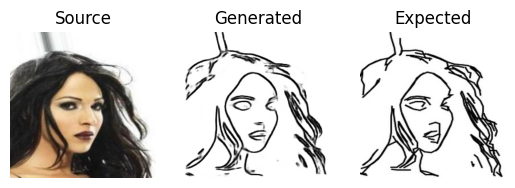

In [21]:
from numpy import load
from numpy import zeros
from numpy import ones
from numpy.random import randint
from numpy import vstack
from keras.optimizers import Adam
from keras.initializers import RandomNormal
from keras.models import Model, load_model
from keras.layers import Input
from keras.layers import Conv2D
from keras.layers import Conv2DTranspose
from keras.layers import LeakyReLU
from keras.layers import Activation
from keras.layers import Concatenate
from keras.layers import Dropout
from keras.layers import BatchNormalization
from keras.layers import LeakyReLU
from matplotlib import pyplot
from google.colab import drive
import zipfile
import cv2

# plot source, generated and target images
def plot_images(src_img, gen_img, tar_img):
	images = vstack((src_img, gen_img, tar_img))
	# scale from [-1,1] to [0,1]
	images = (images + 1) / 2.0
	titles = ['Source', 'Generated', 'Expected']
	# plot images row by row
	for i in range(len(images)):
		# define subplot
		pyplot.subplot(1, 3, 1 + i)
		# turn off axis
		pyplot.axis('off')
		# plot raw pixel data
		pyplot.imshow(images[i])
		# show title
		pyplot.title(titles[i])
	pyplot.show()

drive.mount('/content/drive')
# load image data
output_path = "/content/drive/My Drive/tesina/test-pix2pix/"
dataset_path = "/content/drive/My Drive/tesina/test-pix2pix/CelebAMerged-3k.zip"
dataset = load_real_samples_from_zip(dataset_path)
print('Loaded', dataset[0].shape, dataset[1].shape)
# define input shape based on the loaded dataset
image_shape = dataset[0].shape[1:]
# define the models
d_model = define_discriminator(image_shape)
g_model = define_generator(image_shape)
# define the composite model
gan_model = define_gan(g_model, d_model, image_shape)
# train model
model = train(d_model, g_model, gan_model, dataset, output_path)

# load dataset
print('Loaded', dataset[0].shape, dataset[1].shape)

# load model
model = load_model(output_path + 'model_015000.h5')
summarize_performance(10, model, dataset, output_path, 3)
# select random example
ix = randint(0, len(dataset[0]), 1)
src_image, tar_image = dataset[0][ix], dataset[1][ix]

# select random example
ix = randint(0, len(dataset[0]), 1)
src_image, tar_image = dataset[0][ix], dataset[1][ix]

# generate image from source
gen_image = model.predict(src_image)

# plot all three images
plot_images(src_image, gen_image, tar_image)